# Life Expectancy Prediction from Economic Indicators — Asian Economies (1980-2025)

## Project Objective
This notebook builds a baseline regression model to estimate life expectancy for 20 Asian
countries using economic and social indicators (GDP, population, inflation, unemployment,
school enrollment, and GDP per capita), sourced from the World Bank Open Data API.

The workflow follows a standard supervised-learning pipeline:

1. Data collection (World Bank API)
2. Data quality assessment and cleaning
3. Exploratory data analysis (distributions, correlation, multicollinearity)
4. Feature selection and train/test split
5. Model training (Linear Regression baseline)
6. Evaluation and residual analysis
7. Findings, limitations, and recommendations

## Data Source
World Bank Open Data — https://data.worldbank.org
Licensed under CC BY 4.0 — https://creativecommons.org/licenses/by/4.0/


In [1]:
import requests
from functools import reduce

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import GroupShuffleSplit

from statsmodels.stats.outliers_influence import variance_inflation_factor
import statsmodels.api as sm


## Step 1 — Data Collection

Data is pulled directly from the World Bank API for seven indicators across 20 Asian
countries, covering 1980-2026. The indicator codes are mapped to descriptive names for
readability.

| Indicator | World Bank Code |
|---|---|
| GDP | NY.GDP.MKTP.CD |
| Population | SP.POP.TOTL |
| Life Expectancy | SP.DYN.LE00.IN |
| Inflation | FP.CPI.TOTL.ZG |
| Unemployment | SL.UEM.TOTL.ZS |
| School Enrollment | SE.PRM.NENR |
| GDP per Capita | NY.GDP.PCAP.CD |

**Note:** This step requires network access to `api.worldbank.org`. If you are re-running
this notebook offline, skip to Step 2 and load the previously saved CSV instead.


In [2]:
def get_indicator_multi_country(countries, indicator, start_year, end_year):
    country_str = ";".join(countries)
    url = f"https://api.worldbank.org/v2/country/{country_str}/indicator/{indicator}"
    params = {"format": "json", "per_page": 5000, "date": f"{start_year}:{end_year}"}
    response = requests.get(url, params=params)
    data = response.json()[1]
    
    records = []
    for entry in data:
        if entry["value"] is not None:
            records.append({
                "country": entry["country"]["value"],
                "country_code": entry["countryiso3code"],
                "year": int(entry["date"]),
                "value": entry["value"]
            })
    return pd.DataFrame(records)

indicators = {
    "GDP": "NY.GDP.MKTP.CD",
    "Population": "SP.POP.TOTL",
    "Life_Expectancy": "SP.DYN.LE00.IN",
    "Inflation": "FP.CPI.TOTL.ZG",
    "Unemployment": "SL.UEM.TOTL.ZS",
    "School_Enrollment": "SE.PRM.NENR",
    "GDP_per_capita": "NY.GDP.PCAP.CD"
}

asian_countries = ["IN", "CN", "JP", "KR", "ID", "PK", "BD", "VN", "TH", 
                    "PH", "MY", "SG", "LK", "NP", "MM", "KZ", "SA", "AE", "IR", "IQ"]

all_frames = []
for name, code in indicators.items():
    df_ind = get_indicator_multi_country(asian_countries, code, 1980, 2026)
    df_ind = df_ind.rename(columns={"value": name})[["country", "year", name]]
    all_frames.append(df_ind)

df = reduce(lambda left, right: pd.merge(left, right, on=["country", "year"], how="outer"), all_frames)
print(df.shape)
print(df.head())
print(df["country"].unique())

(920, 9)
      country  year           GDP  Population  Life_Expectancy  Inflation  \
0  Bangladesh  1980  1.813805e+10    88016432           52.278        NaN   
1  Bangladesh  1981  2.024969e+10    90303105           52.638        NaN   
2  Bangladesh  1982  1.852540e+10    92814507           53.012        NaN   
3  Bangladesh  1983  1.760905e+10    95335155           53.441        NaN   
4  Bangladesh  1984  1.892084e+10    97814966           53.826        NaN   

   Unemployment  School_Enrollment  GDP_per_capita  
0           NaN                NaN      206.075714  
1           NaN           68.55957      224.241392  
2           NaN                NaN      199.595945  
3           NaN           65.58304      184.706773  
4           NaN           64.46519      193.435021  
['Bangladesh' 'China' 'India' 'Indonesia' 'Iran, Islamic Rep.' 'Iraq'
 'Japan' 'Kazakhstan' 'Korea, Rep.' 'Malaysia' 'Myanmar' 'Nepal'
 'Pakistan' 'Philippines' 'Saudi Arabia' 'Singapore' 'Sri Lanka'
 'Thailand

Persist the collected dataset to disk so the modeling steps below can be re-run
without repeating the API calls.


In [3]:
filename = "asia_economic_data.csv"
df.to_csv(filename, index=False)
print(f"Saved to {filename}")


Saved to asia_economic_data.csv


## Step 2 — Load Dataset

From this point on, the notebook works from the saved CSV rather than the live API,
which keeps the analysis reproducible.


In [4]:
df = pd.read_csv('asia_economic_data.csv')
df = df.copy()
df


,country,year,GDP,Population,Life_Expectancy,Inflation,Unemployment,School_Enrollment,GDP_per_capita
0,Bangladesh,1980,1.813805e+10,88016432,52.278,NaN,NaN,NaN,206.075714
1,Bangladesh,1981,2.024969e+10,90303105,52.638,NaN,NaN,68.55957,224.241392
2,Bangladesh,1982,1.852540e+10,92814507,53.012,NaN,NaN,NaN,199.595945
3,Bangladesh,1983,1.760905e+10,95335155,53.441,NaN,NaN,65.58304,184.706773
4,Bangladesh,1984,1.892084e+10,97814966,53.826,NaN,NaN,64.46519,193.435021
...,...,...,...,...,...,...,...,...,...
915,Viet Nam,2021,3.664748e+11,98935098,74.145,1.834716,2.383,NaN,3704.193559
916,Viet Nam,2022,4.134452e+11,99680655,74.502,3.156507,1.570,NaN,4147.697772
917,Viet Nam,2023,4.338050e+11,100352192,74.588,3.252893,1.645,NaN,4322.825723
918,Viet Nam,2024,4.763246e+11,100987686,74.736,3.621093,1.602,NaN,4716.659938


## Step 3 — Initial Data Quality Assessment

Before any modeling, check the shape, column types, summary statistics, missing values,
and duplicate rows.


In [5]:
print("Shape of the dataset\n", df.shape)
print("*" * 50)
print("Columns in the dataset\n", df.columns)
print("*" * 50)
print("Statistic details of the dataset\n", df.describe())
print("*" * 50)
print("Data types\n", df.dtypes)
print("*" * 50)
print("Missing values\n", df.isnull().sum())
print("*" * 50)
print("Duplicate rows\n", df.duplicated().sum())
print("*" * 50)


Shape of the dataset
 (920, 9)
**************************************************
Columns in the dataset
 Index(['country', 'year', 'GDP', 'Population', 'Life_Expectancy', 'Inflation',
       'Unemployment', 'School_Enrollment', 'GDP_per_capita'],
      dtype='object')
**************************************************
Statistic details of the dataset
               year           GDP    Population  Life_Expectancy    Inflation  \
count   920.000000  9.040000e+02  9.200000e+02       900.000000   831.000000   
mean   2002.500000  7.438682e+11  1.762405e+08        69.636523    11.160971   
std      13.283139  2.079356e+12  3.443626e+08         7.320108    69.312213   
min    1980.000000  4.077963e+08  1.015700e+06        48.333000   -16.117326   
25%    1991.000000  4.352408e+10  2.034696e+07        64.895000     2.241697   
50%    2002.500000  1.475127e+11  5.154038e+07        69.656000     5.047749   
75%    2014.000000  4.122691e+11  1.248373e+08        74.934085     9.213967   
max  

## Step 4 — Handling Missing Values

Strategy:

- For feature columns (GDP, Inflation, Unemployment, School Enrollment, GDP per capita),
  missing values are imputed with the **country-level median**. This preserves each
  country's typical economic profile instead of pulling values toward a global average.
- Rows missing the **target variable** (`Life_Expectancy`) are dropped, since a missing
  target cannot be imputed for a supervised learning task without introducing bias.


In [6]:
null_cols = df.columns[df.isnull().sum() > 0].tolist()
null_cols = [col for col in null_cols if col != 'Life_Expectancy']
print(null_cols)
for col in null_cols:
    df[col]=df[col].fillna(df.groupby('country')[col].transform('median'))
df = df.dropna(subset=['Life_Expectancy'])
print(df.isnull().sum())

['GDP', 'Inflation', 'Unemployment', 'School_Enrollment', 'GDP_per_capita']
country               0
year                  0
GDP                   0
Population            0
Life_Expectancy       0
Inflation             0
Unemployment          0
School_Enrollment    45
GDP_per_capita        0
dtype: int64


Confirm that `Life_Expectancy` is now populated for every country in the cleaned dataset.

In [7]:
print(df[['country', 'Life_Expectancy']].sort_values('country'))

        country  Life_Expectancy
0    Bangladesh           52.278
25   Bangladesh           65.509
26   Bangladesh           66.048
27   Bangladesh           66.458
28   Bangladesh           67.047
..          ...              ...
891    Viet Nam           71.670
892    Viet Nam           72.283
893    Viet Nam           72.575
883    Viet Nam           68.805
918    Viet Nam           74.736

[900 rows x 2 columns]


### Special Case: School Enrollment for Japan

Country-level median imputation cannot fill a column that is **entirely missing** for a
given country. Japan has no reported `School_Enrollment` values in the source data, so a
domain-informed constant (100, reflecting Japan's near-universal primary enrollment) is
used instead.


In [8]:
# Check for country-wise School_Enrollment null values
print(df[df['School_Enrollment'].isna()]['country'].value_counts())


country
Japan    45
Name: count, dtype: int64


In [9]:
# For Japan, all School_Enrollment values are missing; impute 100 (near-universal enrollment)
df.loc[df['country'] == 'Japan', 'School_Enrollment'] = 100
print("After imputing\n", df['School_Enrollment'].isnull().sum())


After imputing
 0


## Step 5 — Skewness and Outlier Assessment

For each numeric feature (excluding the target), compute skewness and flag outliers using
the IQR rule (values beyond 1.5x IQR from Q1/Q3). Features with `|skew| > 0.5` are
considered candidates for transformation.


In [10]:
def check_skew_outlier(df):
    num_cols=df.select_dtypes(include='number').drop(columns='Life_Expectancy')
    outlier_counts = {}
    for col in num_cols.columns:
        Q1 = df[col].quantile(0.25)
        Q3 = df[col].quantile(0.75)
        IQR = Q3 - Q1
        outliers = df[(df[col] < Q1 - 1.5*IQR) | (df[col] > Q3 + 1.5*IQR)]
        outlier_counts[col] = len(outliers)
    
    result = pd.DataFrame({
        'Skew': num_cols.skew(),
        'Outlier_Count': pd.Series(outlier_counts)
    })
    high_skews = result[result['Skew'].abs() > 0.5]
 
    return high_skews

In [11]:
print("Skew and Outlier — Before")
high_skew = check_skew_outlier(df)
print(high_skew)

# Apply a signed log1p transform to reduce skew in flagged columns
for col in high_skew.index:
    df[col] = np.sign(df[col]) * np.log1p(abs(df[col]))

print("Skew and Outlier — After")
high_skew = check_skew_outlier(df)
print(high_skew)


Skew and Outlier — Before
                        Skew  Outlier_Count
GDP                 5.704388            124
Population          2.695402             91
Inflation          25.119260             74
Unemployment        0.956055             29
School_Enrollment  -1.782659             95
GDP_per_capita      2.332965            134
Skew and Outlier — After
                       Skew  Outlier_Count
School_Enrollment -2.027157             98


C:\Users\spppy\AppData\Local\Temp\ipykernel_9448\1573934707.py:7: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df[col] = np.sign(df[col]) * np.log1p(abs(df[col]))


## Step 6 — Outlier Visualization

A boxplot across all numeric features gives a quick visual cross-check against the IQR
outlier counts above. `School_Enrollment` remains skewed even after the log transform,
which is expected: it is a bounded percentage (0-100), and a log transform is not well
suited to bounded variables. This is revisited in the Findings section.


In [12]:
num_cols=df.select_dtypes(include='number').drop(columns='Life_Expectancy')

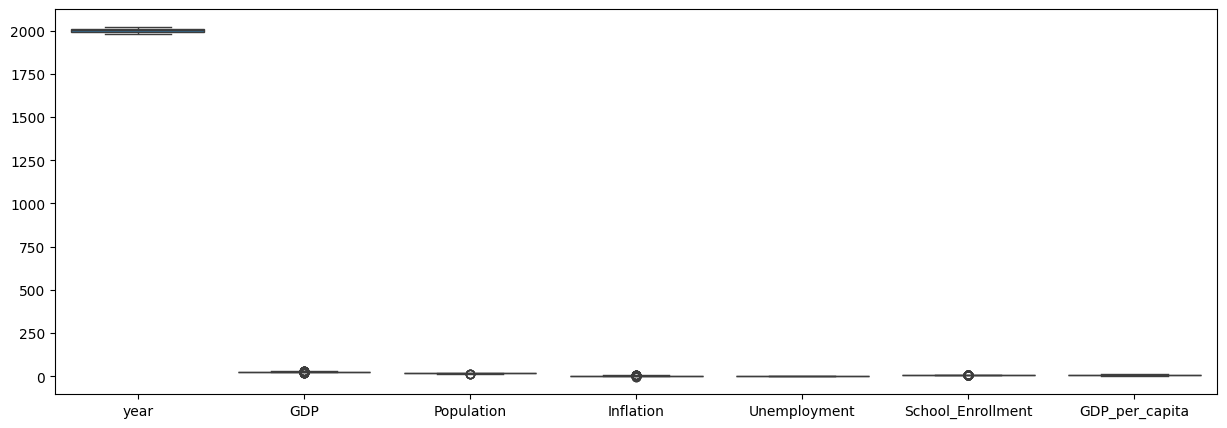

In [13]:
plt.figure(figsize=(15,5))
sns.boxplot(data=num_cols)
plt.show()

## Step 7 — Feature Distributions

Histograms with kernel density estimates for each numeric feature.


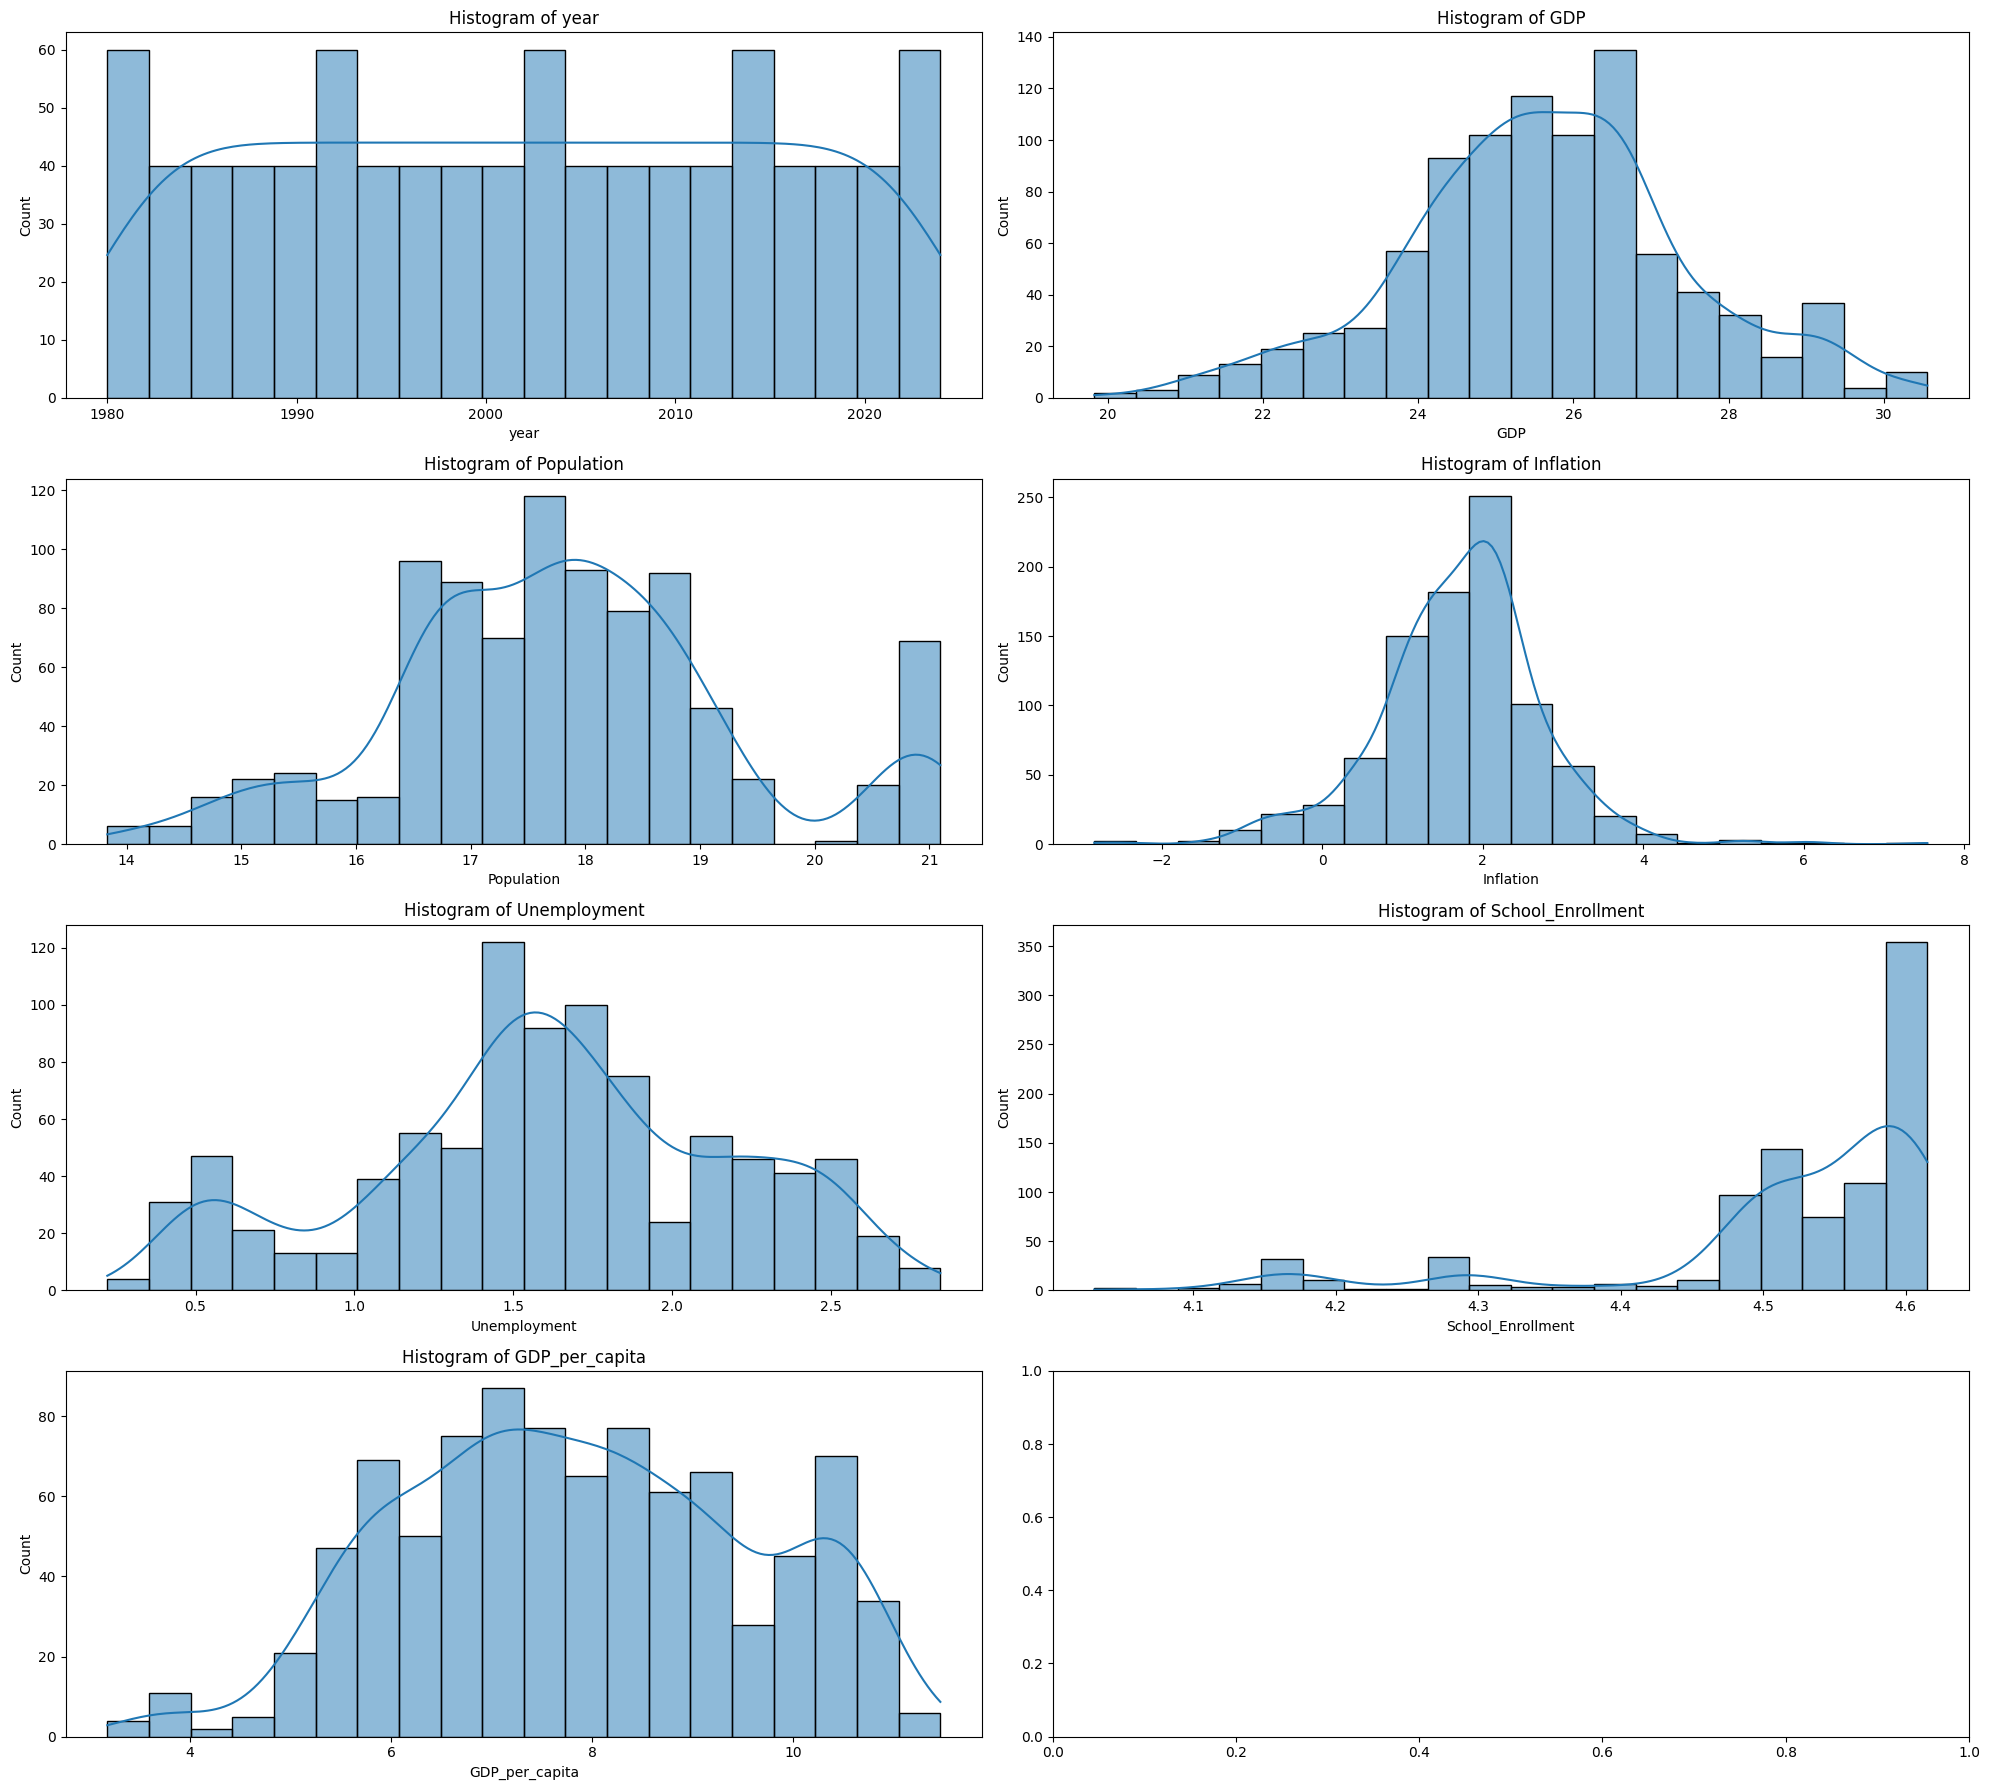

In [14]:
#Visualize Distributions → histograms (with KDE) for all numeric columns
fig, axes = plt.subplots(4, 2, figsize=(20, 18))
axes = axes.flatten()
for i, col in enumerate(num_cols):
    sns.histplot(df[col], kde=True, bins=20, ax=axes[i])
    axes[i].set_title(f"Histogram of {col}")
plt.tight_layout()
plt.show()

## Step 8 — Correlation Analysis

Pairwise correlations between numeric features, visualized as a heatmap to spot
candidates for multicollinearity before modeling.


Correlation Matrix:
                        year       GDP  Population  Inflation  Unemployment  \
year               1.000000  0.508361    0.155871  -0.159112      0.039876   
GDP                0.508361  1.000000    0.478999  -0.381585      0.018137   
Population         0.155871  0.478999    1.000000   0.111278     -0.008840   
Inflation         -0.159112 -0.381585    0.111278   1.000000      0.170107   
Unemployment       0.039876  0.018137   -0.008840   0.170107      1.000000   
School_Enrollment  0.059941  0.224704   -0.146086  -0.209150      0.154296   
GDP_per_capita     0.406144  0.645176   -0.361473  -0.501791      0.027720   

                   School_Enrollment  GDP_per_capita  
year                        0.059941        0.406144  
GDP                         0.224704        0.645176  
Population                 -0.146086       -0.361473  
Inflation                  -0.209150       -0.501791  
Unemployment                0.154296        0.027720  
School_Enrollment       

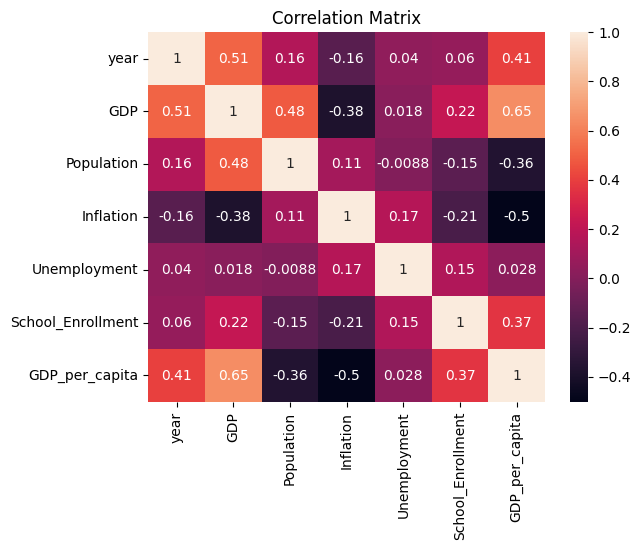

In [15]:
# Correlation matrix
print("Correlation Matrix:\n", num_cols.corr())

# Heatmap
sns.heatmap(num_cols.corr(), annot=True)
plt.title("Correlation Matrix")
plt.show()


## Step 9 — Multicollinearity Check (VIF)

`GDP_per_capita` is mathematically derived from `GDP` and `Population`
(`GDP_per_capita = GDP / Population`), which introduces structural multicollinearity.
It is excluded from this VIF check and from the final feature set, and `GDP` and
`Population` are kept as the underlying drivers instead.


In [16]:
x1 = df.drop(columns=['Life_Expectancy', 'country', 'GDP_per_capita'])
x_with_const = sm.add_constant(x1)

vif_data = pd.DataFrame()
vif_data['feature'] = x_with_const.columns
vif_data['VIF'] = [variance_inflation_factor(x_with_const.values, i)
                    for i in range(x_with_const.shape[1])]

# Drop the intercept row — it is not a real feature
vif_data = vif_data[vif_data['feature'] != 'const'].reset_index(drop=True)

print(vif_data.sort_values(by="VIF"))


             feature       VIF
4       Unemployment  1.079336
5  School_Enrollment  1.202354
0               year  1.394571
3          Inflation  1.427615
2         Population  1.656755
1                GDP  2.471916


## Step 10 — Feature Selection

VIF values are all well below the common threshold of 5, so no feature needs to be
dropped for collinearity beyond `GDP_per_capita` (already excluded above).

**Design decision — `country` is not encoded as a feature.** The final model drops the
`country` column entirely rather than one-hot or label encoding it. This keeps the model
simple and avoids adding 19 extra parameters on a modest dataset, but it also means the
model cannot learn country-specific baselines (see Findings for the consequence of this
choice).


In [17]:
x=df.drop(columns=['Life_Expectancy','GDP_per_capita'])
y = df['Life_Expectancy']

## Step 11 — Train/Test Split (Grouped by Country)

A standard random split would let years from the same country appear in both train and
test sets, inflating apparent performance. `GroupShuffleSplit` instead assigns entire
countries to either train (75%) or test (25%), so the model is evaluated on countries it
has not seen during training.


In [18]:
# Split by country group: 75% of countries for training, 25% for testing
gss = GroupShuffleSplit(n_splits=1, train_size=0.75, random_state=42)
train_idx, test_idx = next(gss.split(x, y, groups=x['country']))

xtrain = x.iloc[train_idx].drop(columns=['country'])
xtest = x.iloc[test_idx].drop(columns=['country'])
ytrain = y.iloc[train_idx]
ytest = y.iloc[test_idx]


## Step 12 — Feature Scaling

Standardize features (zero mean, unit variance) using statistics from the training set
only, then apply the same transform to the test set to avoid data leakage.


In [19]:
scaler = StandardScaler()
xtrain_scaled = scaler.fit_transform(xtrain)
xtest_scaled = scaler.transform(xtest)

## Step 13 — Model Training

A Linear Regression baseline is trained first. It offers interpretable coefficients and
serves as a benchmark before trying regularized alternatives (Ridge, Lasso) or
non-linear models.


In [20]:
model = LinearRegression()
model.fit(xtrain_scaled, ytrain)


,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


## Step 14 — Prediction on the Test Set

In [21]:
#predict
ypred=model.predict(xtest_scaled)

## Step 15 — Predicted vs Actual

Points close to the diagonal line indicate accurate predictions; systematic deviation
from the line indicates bias.


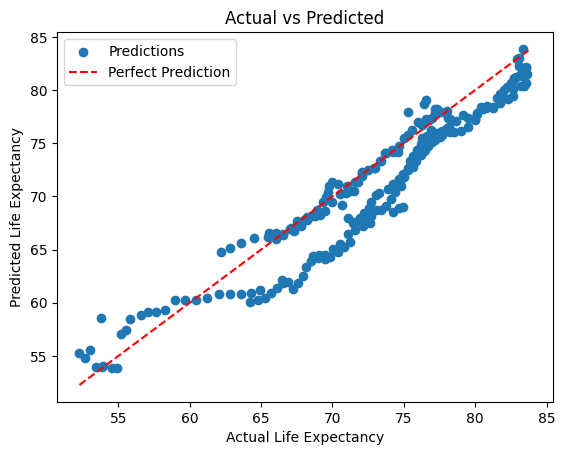

In [22]:
plt.scatter(ytest, ypred, label="Predictions")

# Diagonal line: predicted = actual (perfect prediction)
min_val = min(ytest.min(), ypred.min())
max_val = max(ytest.max(), ypred.max())
plt.plot([min_val, max_val], [min_val, max_val], color="red", linestyle="--", label="Perfect Prediction")

plt.xlabel("Actual Life Expectancy")
plt.ylabel("Predicted Life Expectancy")
plt.title("Actual vs Predicted")
plt.legend()
plt.show()

## Step 16 — Evaluation Metrics

RMSE and R² on the held-out (unseen-country) test set.


In [23]:
# Calculating metrics
lr_mse = mean_squared_error(ytest, ypred)
lr_mae = mean_absolute_error(ytest, ypred)
lr_rmse = np.sqrt(lr_mse)
lr_r2 = r2_score(ytest, ypred)

print("RMSE:", lr_rmse)
print("MAE:", lr_mae)
print("R2 Score:", lr_r2)


RMSE: 2.6888670215497292
MAE: 2.136177281507058
R2 Score: 0.8670322605422894


## Step 17 — Residual Analysis by Country

Aggregate metrics can hide systematic bias. Here, the correlation between prediction
error and year is checked **within each test-set country**, and China and Bangladesh are
inspected in detail as the two ends of that pattern.


In [24]:
results_df = pd.DataFrame({
    'country': x.iloc[test_idx]['country'].values,
    'year': x.iloc[test_idx]['year'].values,
    'actual': ytest.values,
    'predicted': ypred
})
results_df['error'] = abs(results_df['actual'] - results_df['predicted'])

# Check if error correlates with year
print(results_df.groupby('country')[['year', 'error']].corr())

# Specifically look at China and Bangladesh's error by year
for country in ['China', 'Bangladesh']:
    subset = results_df[results_df['country'] == country].sort_values('year')
    print(f"\n{country}:")
    print(subset[['year', 'actual', 'predicted', 'error']])

                       year     error
country                              
Bangladesh  year   1.000000  0.625040
            error  0.625040  1.000000
China       year   1.000000 -0.876754
            error -0.876754  1.000000
Korea, Rep. year   1.000000  0.858171
            error  0.858171  1.000000
Singapore   year   1.000000 -0.655006
            error -0.655006  1.000000
Thailand    year   1.000000 -0.046445
            error -0.046445  1.000000

China:
    year  actual  predicted     error
45  1980  64.243  60.044136  4.198864
46  1981  64.778  60.245474  4.532526
47  1982  65.249  60.494295  4.754705
48  1983  65.728  60.914998  4.813002
49  1984  66.148  61.343089  4.804911
50  1985  66.532  61.901703  4.630297
51  1986  66.887  61.971134  4.915866
52  1987  67.263  61.300144  5.962856
53  1988  67.607  61.828607  5.778393
54  1989  67.930  62.515089  5.414911
55  1990  68.155  63.322289  4.832711
56  1991  68.610  64.363850  4.246150
57  1992  69.059  64.457795  4.601205
58  

## Findings and Conclusions

**Model performance.** The baseline Linear Regression model achieves **R² = 0.87** and
**RMSE = 2.69 years** on countries held out entirely from training. In practical terms,
predictions are typically within about 2-3 years of actual life expectancy for a country
the model has never seen — a reasonable result for a simple linear baseline on
macroeconomic indicators.

**Systematic bias by country and year.** Residual analysis shows the error is not random
with respect to time within a country:

- China: error and year are strongly negatively correlated (-0.88) — the model
  under-predicts life expectancy in earlier decades and the gap narrows over time.
- Korea, Rep.: strongly positively correlated (+0.86) — the error grows over time.
- Bangladesh: moderately positive (+0.63).
- Singapore: moderately negative (-0.66).
- Thailand: near zero (-0.05), i.e. no clear time trend.

This indicates that a single global linear trend does not capture each country's actual
life expectancy trajectory. Countries have improved health outcomes at different rates
and starting points that a linear combination of GDP, population, inflation,
unemployment, and school enrollment does not fully explain.

**Country identity is not modeled.** Because `country` was dropped rather than encoded,
the model has no way to learn a country-specific baseline or trend — which is the most
likely explanation for the residual pattern above.

**The log transform on School_Enrollment had no measurable effect.** Outlier count was
98 both before and after the transform, and skew barely changed (-2.03 to -2.07). This is
expected: `School_Enrollment` is a bounded percentage (0-100), and a `log1p` transform —
designed for right-skewed, unbounded positive data — is not an appropriate tool for a
bounded, left-skewed variable. A logit-style transform, or leaving the variable
untransformed, would be more appropriate.

## Recommendations for Next Steps

1. **Add country structure to the model.** Either one-hot encode `country` (already
   imported via `pd.get_dummies` as an option) to give each country its own intercept, or
   move to a panel/mixed-effects model that explicitly models country and time effects.
2. **Try regularized regression.** `Ridge` and `Lasso` are already imported; comparing
   them against the plain Linear Regression baseline would show whether multicollinearity
   or overfitting is affecting the coefficients.
3. **Revisit the School_Enrollment transform.** Use a logit-style transform for this
   bounded percentage variable, or leave it untransformed and rely on tree-based models
   that don't assume a particular distribution.
4. **Consider a time-aware split or trend features.** Adding `year` as an explicit trend
   term per country, or using a rolling/expanding time-based validation scheme, would
   better test the model's ability to extrapolate forward in time — which is the more
   realistic use case for this kind of indicator.
5. **Benchmark against a non-linear model** (e.g. Random Forest or Gradient Boosting) to
   quantify how much of the residual pattern is due to the linear-model assumption versus
   missing country/time structure.
